In [7]:
#Load and Explore the data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from matplotlib.colors import ListedColormap

# Load the dataset
df = pd.read_csv("/content/Zoo.csv")

# Display basic info
print("Dataset Info:")
print(df.info())

# Display first few rows
print("\nFirst 5 Rows:")
print(df.head())



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   animal name  101 non-null    object
 1   hair         101 non-null    int64 
 2   feathers     101 non-null    int64 
 3   eggs         101 non-null    int64 
 4   milk         101 non-null    int64 
 5   airborne     101 non-null    int64 
 6   aquatic      101 non-null    int64 
 7   predator     101 non-null    int64 
 8   toothed      101 non-null    int64 
 9   backbone     101 non-null    int64 
 10  breathes     101 non-null    int64 
 11  venomous     101 non-null    int64 
 12  fins         101 non-null    int64 
 13  legs         101 non-null    int64 
 14  tail         101 non-null    int64 
 15  domestic     101 non-null    int64 
 16  catsize      101 non-null    int64 
 17  type         101 non-null    int64 
dtypes: int64(17), object(1)
memory usage: 14.3+ KB
None

Fir

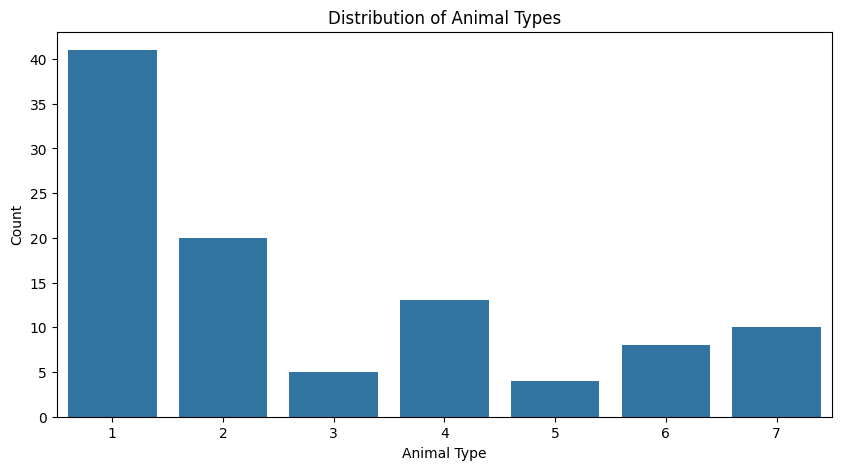

In [8]:
#Data Visualization
# Count of each animal type
plt.figure(figsize=(10, 5))
sns.countplot(x=df['type'])
plt.title("Distribution of Animal Types")
plt.xlabel("Animal Type")
plt.ylabel("Count")
plt.show()

In [9]:
#data Preprocessing
# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())



Missing Values:
animal name    0
hair           0
feathers       0
eggs           0
milk           0
airborne       0
aquatic        0
predator       0
toothed        0
backbone       0
breathes       0
venomous       0
fins           0
legs           0
tail           0
domestic       0
catsize        0
type           0
dtype: int64


In [12]:
#Slpit the Data
# Split data into features and target
X = df.drop(columns=['animal name', 'type'])  # Drop non-numeric columns
y = df['type']

# Select two features for visualization (e.g., 'hair' and 'feathers')
X_vis = X[['hair', 'feathers']]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_vis, y, test_size=0.2, random_state=42)

# Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [13]:
#implement KNN Classifier
# Implement KNN Classifier
k = 5  # Choose K value
knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
knn.fit(X_train, y_train)

# Predictions
y_pred = knn.predict(X_test)


In [14]:
#Evaluate the Model
# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.6666666666666666

Classification Report:
               precision    recall  f1-score   support

           1       0.85      0.92      0.88        12
           2       1.00      1.00      1.00         2
           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         2
           6       0.17      0.33      0.22         3
           7       0.00      0.00      0.00         1

    accuracy                           0.67        21
   macro avg       0.34      0.38      0.35        21
weighted avg       0.60      0.67      0.63        21


Confusion Matrix:
 [[11  0  0  0  1  0]
 [ 0  2  0  0  0  0]
 [ 0  0  0  0  1  0]
 [ 0  0  0  0  2  0]
 [ 2  0  0  0  1  0]
 [ 0  0  0  0  1  0]]


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


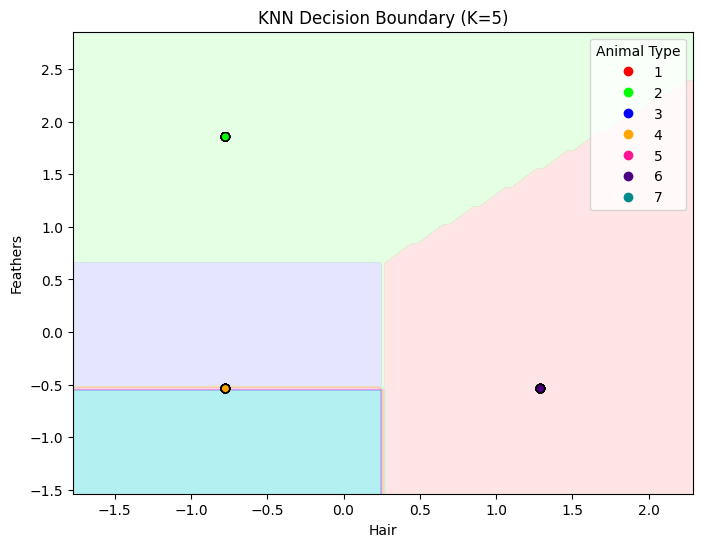

In [15]:
#Visualize Decision Boundaries
# Decision Boundary Visualization
x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
y_min, y_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF', '#FFD700', '#FF69B4', '#8A2BE2', '#00CED1']))
scatter = plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=ListedColormap(['#FF0000', '#00FF00', '#0000FF', '#FFA500', '#FF1493', '#4B0082', '#008B8B']), edgecolor='k')
plt.xlabel('Hair')
plt.ylabel('Feathers')
plt.title(f'KNN Decision Boundary (K={k})')
plt.legend(*scatter.legend_elements(), title="Animal Type")
plt.show()

# **Interview Questions**
**1. What are the key hyperparameters in KNN?**
* Number of neighbors (K)
* Distance metric (Euclidean, Manhattan, etc.)
* Weighting method (uniform, distance-based)

**2. What distance metrics can be used in KNN?**

* Euclidean distance
* Manhattan distance
* Minkowski distance
* Hamming distance (for categorical data)